# V1 vs V2 Comparison: Parametric Maps and TIC

Side-by-side comparison of CEUS parametric maps and time intensity curves between two patient visits (e.g. pre- and post-treatment). Paramap `.npy` files for each visit are loaded, axes are aligned to the image volume, and representative axial slices of PE and AUC are displayed in a grid. A whole-VOI TIC is computed for each visit, fitted with a lognormal model, and plotted together so AUC, PE, and MTT changes between visits can be assessed visually.

In [1]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path

print(Path().cwd())
os.chdir(Path(os.getcwd()).parent)
print(Path().cwd())

/Users/samantha/QuantUS-Plugins-CEUS/China_Data
/Users/samantha/QuantUS-Plugins-CEUS


### Setup

Reload modules and set working directory to the repo root.

### Configuration — set paths and patient ID here

In [161]:
from pathlib import Path

# Set these to your paramap output folders for each visit
V1_DIR = "/Users/samantha/Desktop/tul/china data/p11/new_v1/necrotic_paramap"
V2_DIR = "/Users/samantha/Desktop/tul/china data/p11/new_v3/necrotic_paramap"

LABEL = "P11 Necrosis Removed"   # Used for plot titles only

# B-mode frame to show as background
FRAME = 80

print(f"V1 dir exists: {Path(V1_DIR).exists()}")
print(f"V2 dir exists: {Path(V2_DIR).exists()}")

V1 dir exists: True
V2 dir exists: True


### Load data

In [162]:
import numpy as np

def load_visit(base_dir):
    base_dir = Path(base_dir)
    im  = np.load(base_dir / 'image.npy')                    # (sag, cor, ax, t)
    seg = np.load(base_dir / 'segmentation.npy')             # (sag, cor, ax)
    pe  = np.load(base_dir / 'PE_full_TIC_numerical.npy')
    auc = np.load(base_dir / 'AUC_full_TIC_numerical.npy')
    pix = np.load(base_dir / 'pix_dims.npy') if (base_dir / 'pix_dims.npy').exists() else None
    return {'im': im, 'seg': seg, 'pe': pe, 'auc': auc, 'pix': pix}

v1 = load_visit(V1_DIR)
v2 = load_visit(V2_DIR)

### Align paramaps to image axes and pick 3 representative slices

In [163]:
from itertools import permutations

def align_pm_to_im(pm, im):
    """Permute paramap axes to match image spatial shape."""
    target = im.shape[:3]
    for p in permutations(range(3)):
        if tuple(pm.shape[i] for i in p) == target:
            return np.transpose(pm, p)
    raise ValueError(f"Cannot align paramap {pm.shape} to image {target}")

def pick_slices(pm, n=5):
    """Pick n slices evenly spread across slices that have meaningful data."""
    counts = np.array([
        np.sum(np.isfinite(pm[:, :, xi]) & (pm[:, :, xi] > 0))
        for xi in range(pm.shape[2])
    ])
    threshold = max(counts) * 0.10
    valid_indices = np.where(counts >= threshold)[0]
    if len(valid_indices) < n:
        valid_indices = np.argsort(counts)[-n:]
        valid_indices = np.sort(valid_indices)
    # Evenly spaced from valid range
    idx = np.round(np.linspace(0, len(valid_indices) - 1, n)).astype(int)
    return [int(valid_indices[i]) for i in idx]

for d in [v1, v2]:
    d['pe_aligned']  = align_pm_to_im(d['pe'],  d['im'])
    d['auc_aligned'] = align_pm_to_im(d['auc'], d['im'])
    d['slices'] = pick_slices(d['pe_aligned'], n=5)

print(f"V1 slices: {v1['slices']}")
print(f"V2 slices: {v2['slices']}")

V1 slices: [9, 23, 37, 52, 66]
V2 slices: [63, 73, 83, 92, 102]


### PE and AUC paramap slices — V1 vs V2

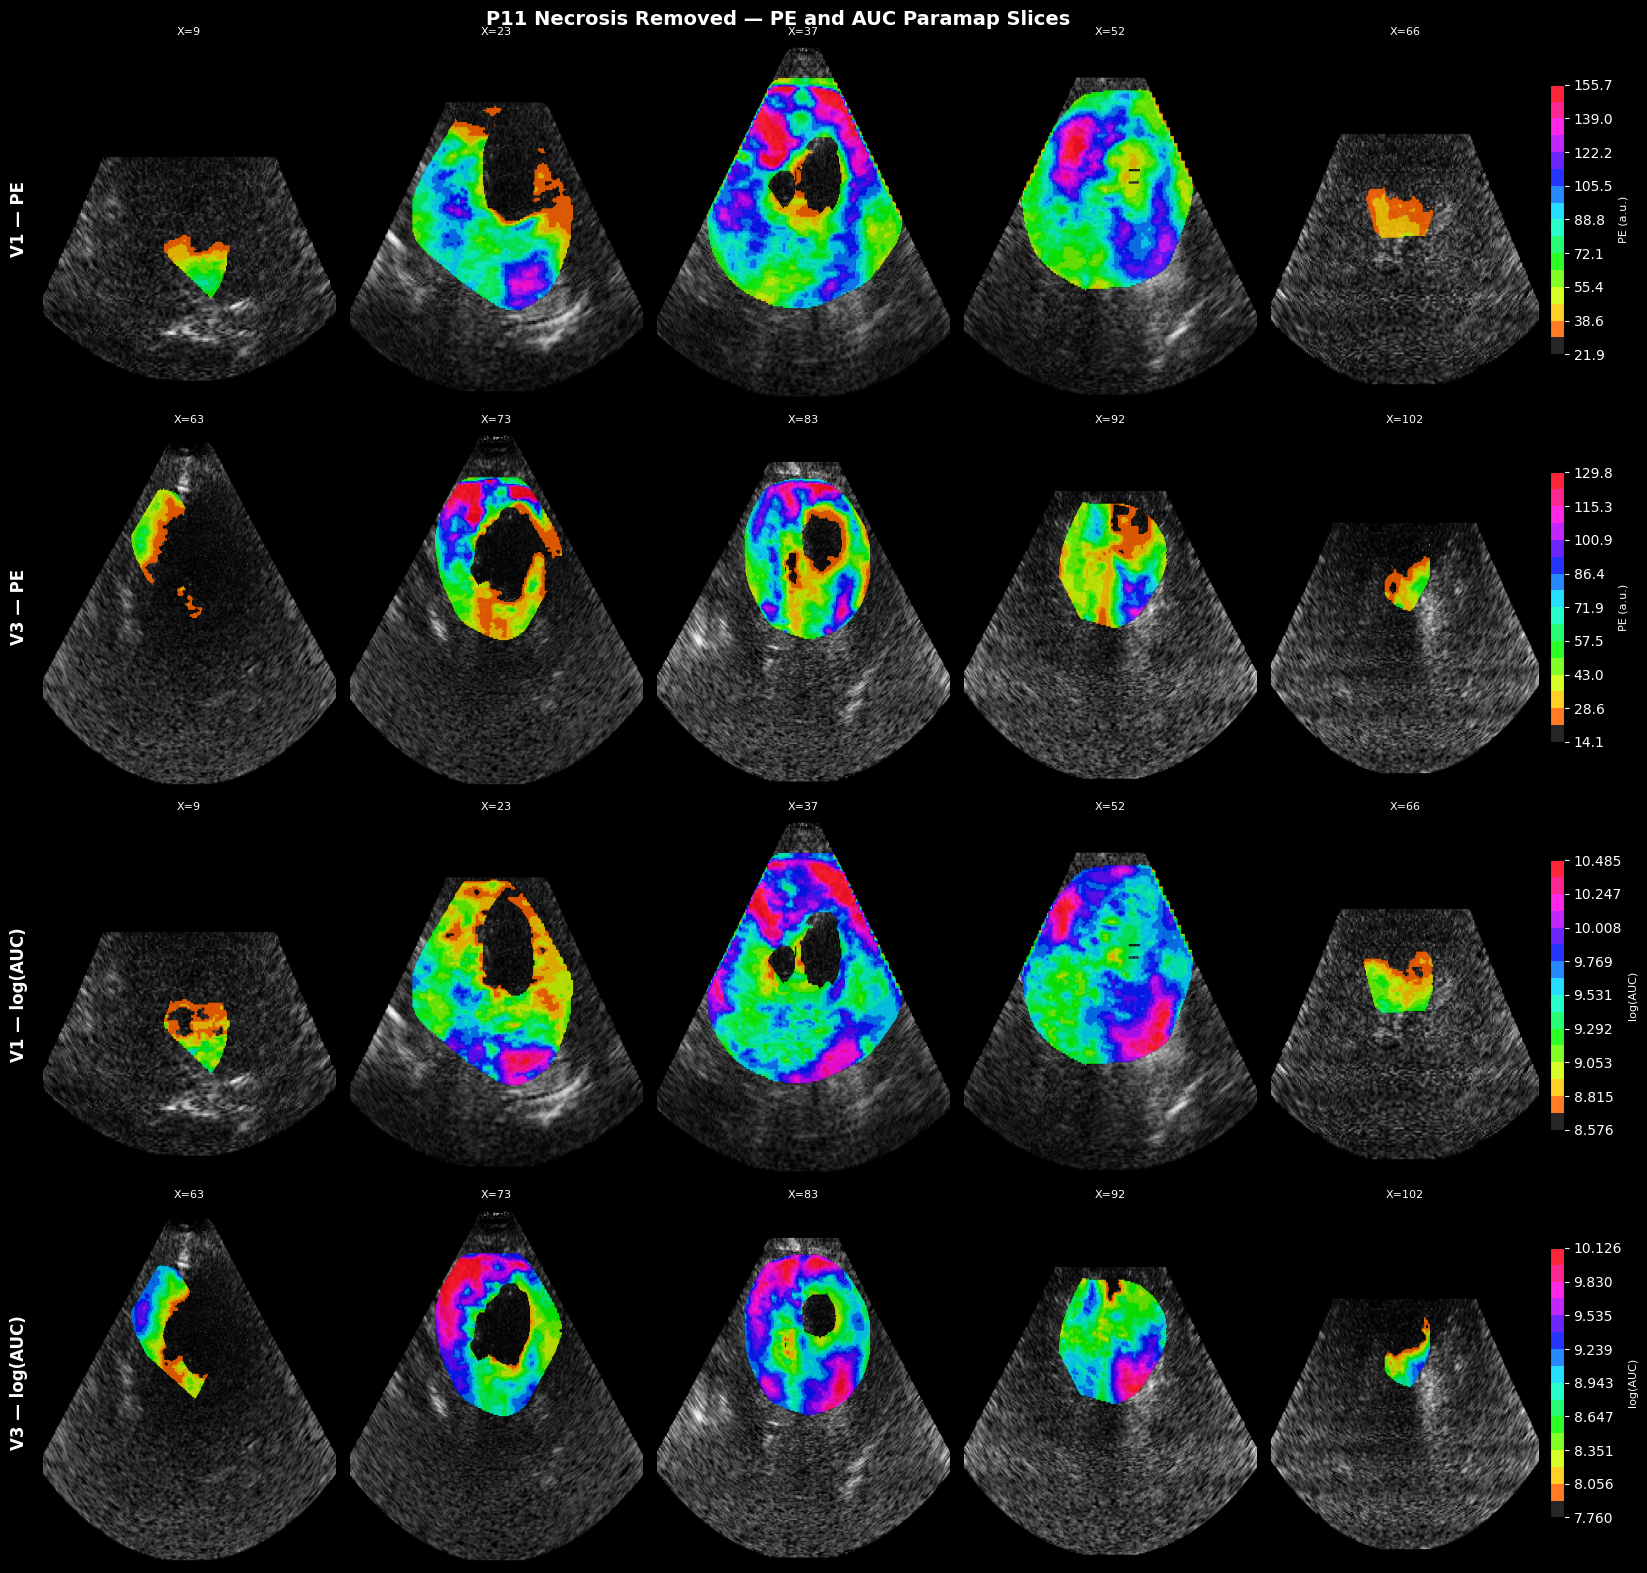

In [164]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

N_BINS = 16
N_SLICES = 5

def make_discrete_cmap(data, seg, log=False):
    """HSV discrete colormap matching paramap_visualization.ipynb."""
    d = np.where(np.isfinite(data) & (data > 0), np.log(data) if log else data, np.nan)
    valid = d[(seg > 0) & np.isfinite(d)]
    vmin = float(np.percentile(valid, 1))
    vmax = float(np.percentile(valid, 99))
    base = plt.get_cmap('hsv', N_BINS)
    colors = np.array([base(i) for i in range(N_BINS)])
    colors[0] = [0.0, 0.0, 0.0, 0.0]
    listed = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(np.linspace(vmin, vmax, N_BINS + 1), listed.N)
    return listed, norm

row_configs = [
    (v1, 'pe_aligned',  False, 'PE (a.u.)',  'V1 — PE'),
    (v2, 'pe_aligned',  False, 'PE (a.u.)',  'V3 — PE'),
    (v1, 'auc_aligned', True,  'log(AUC)',   'V1 — log(AUC)'),
    (v2, 'auc_aligned', True,  'log(AUC)',   'V3 — log(AUC)'),
]

fig, axes = plt.subplots(4, N_SLICES, figsize=(N_SLICES * 3.5, 4 * 4))
fig.patch.set_facecolor('black')

for row_i, (d, pm_key, do_log, cbar_label, row_label) in enumerate(row_configs):
    pm = d[pm_key]
    seg = d['seg']
    cmap, norm = make_discrete_cmap(pm, seg, log=do_log)

    for col_i, xi in enumerate(d['slices']):
        ax = axes[row_i, col_i]

        pm_slice = (np.log(pm[:, :, xi]) if do_log else pm[:, :, xi]).astype(float)
        pm_slice[seg[:, :, xi] == 0] = np.nan

        ax.imshow(np.rot90(d['im'][:, :, xi, FRAME], k=3), cmap='gray', aspect='auto')
        masked = np.ma.masked_invalid(np.rot90(pm_slice, k=3))
        mappable = ax.imshow(masked, cmap=cmap, norm=norm, alpha=0.85, aspect='auto')
        ax.set_title(f'X={xi}', fontsize=8, color='white', pad=3)
        ax.axis('off')

        if col_i == N_SLICES - 1:
            cbar = fig.colorbar(mappable, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label(cbar_label, fontsize=8, color='white')
            cbar.ax.yaxis.set_tick_params(color='white')
            plt.setp(cbar.ax.get_yticklabels(), color='white')

    # Row label as text on the first axis
    axes[row_i, 0].text(
        -0.05, 0.5, row_label,
        transform=axes[row_i, 0].transAxes,
        fontsize=12, color='white', fontweight='bold',
        va='center', ha='right', rotation=90
    )

plt.suptitle(f'{LABEL} — PE and AUC Paramap Slices', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(left=0.08)
plt.show()

### Whole-VOI TIC + lognormal fit — V1 vs V2

In [165]:
import sys
sys.path.insert(0, str(Path('.').resolve()))

from src.curve_quantification.transforms import bolus_lognormal_no_t0, fit_lognormal_curve_no_t0

def compute_tic(d):
    img  = d['im']   # (sag, cor, ax, t)
    mask = d['seg']  # (sag, cor, ax)
    n_frames = img.shape[3]

    tic = np.array([
        np.exp(img[:, :, :, t][mask > 0] / 24.09).mean()
        for t in range(n_frames)
    ])

    # Baseline subtraction (same as GUI)
    tic = tic - np.mean(tic[:2])
    if np.any(tic < 0):
        tic = tic + np.abs(np.min(tic))
    else:
        tic = tic - np.min(tic)

    time_arr = np.arange(n_frames, dtype=float)  # fps=1
    return tic, time_arr

v1['tic'], v1['time'] = compute_tic(v1)
v2['tic'], v2['time'] = compute_tic(v2)

print(f"V1 TIC max: {np.max(v1['tic']):.2f}  frames: {len(v1['tic'])}")
print(f"V2 TIC max: {np.max(v2['tic']):.2f}  frames: {len(v2['tic'])}")

V1 TIC max: 157.61  frames: 181
V2 TIC max: 52.95  frames: 153


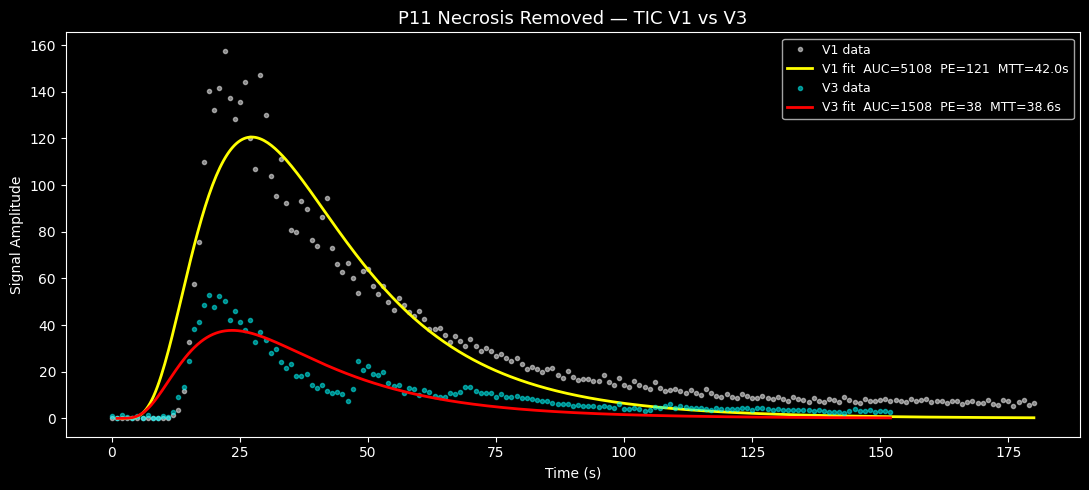

In [166]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

visit_configs = [
    (v1, 'V1', 'white',  'yellow'),
    (v2, 'V3', 'cyan',   'red'),
]

for d, visit, color_data, color_fit in visit_configs:
    tic = d['tic']
    time_arr = d['time']
    result = fit_lognormal_curve_no_t0(time_arr.copy(), tic.copy())
    auc, pe, tp, mtt, mu, sigma, pe_loc, tmppv = result

    ax.plot(time_arr, tic, 'o', color=color_data, markersize=3, alpha=0.5, label=f'{visit} data')

    if not np.isnan(auc):
        t_fit = np.linspace(time_arr[1], time_arr[-1], 500)
        fitted = bolus_lognormal_no_t0(t_fit, auc, mu, sigma) * tmppv
        ax.plot(t_fit, fitted, '-', color=color_fit, linewidth=2,
                label=f'{visit} fit  AUC={auc*tmppv:.0f}  PE={pe*tmppv:.0f}  MTT={mtt:.1f}s')
    else:
        print(f"{visit}: fit failed")

ax.set_xlabel('Time (s)', color='white')
ax.set_ylabel('Signal Amplitude', color='white')
ax.set_title(f'{LABEL} — TIC V1 vs V3', color='white', fontsize=13)
ax.tick_params(colors='white')
ax.spines[:].set_color('white')
ax.legend(fontsize=9, facecolor='black', labelcolor='white')

plt.tight_layout()
plt.show()


### Plot TIC with Lognormal Fit — V1 vs V2

Plot raw TIC data and fitted lognormal curves for both visits side-by-side, annotated with AUC, PE, and MTT values.